# Smart Microscopy v3 - Adaptive Target Acquisition

Two-objective workflow: acquire an overview scan at the source objective,
segment cells with cellpose, then re-acquire selected targets at the
target objective.

**Workflow steps:**

| Step | What happens | Operator action before running |
|------|-------------|-------------------------------|
| 0. Preflight | Calibration, engine boot, slot derivation | Connect LAS X |
| 1. Stage limits | Derive XY limits from markers, enforce z-wide | Place boundary markers in Navigator Expert |
| 2. Scan field | Read tile positions from template | Draw scan field in Navigator Expert |
| 3. Focus map | AF at markers, fit z-wide surface model | Place focus markers on scan field |
| 4. Overview | Acquire tiles, segment + pick cells | - |
| 5. Targets | Acquire each picked cell at target objective | - |
| 6. Summary | Write results, plot, restore, shutdown | - |
| 7. Cleanup | Safe shutdown (run after any failure) | - |

All logic lives in `notebooks/workflow/`. This notebook is a thin
operator-facing wrapper. See `TARGET_ACQUISITION_DESIGN.md` for the
full design.

In [12]:
import sys
from pathlib import Path

_HERE = Path.cwd()
for _c in [_HERE / "controller/vendor/leica/navigator_expert/notebooks",
           _HERE,
           _HERE / "notebooks",
           _HERE.parent / "notebooks"]:
    if (_c / "workflow" / "__init__.py").exists():
        sys.path.insert(0, str(_c.resolve()))
        break
else:
    raise RuntimeError(
        "Could not find notebooks/workflow/. Launch Jupyter from the "
        "smart-microscopy repo root, navigator_expert/, or "
        "navigator_expert/notebooks/."
    )

from workflow import Config

## Configuration

Edit the cell below to match your experiment. Everything else runs
without modification.

**Operating modes** (set `analysis_image_source`):

| Mode | Value | Use case |
|------|-------|----------|
| Real microscope | `"acquired"` | Production: analyse the actual acquired tiles |
| Simulator / dry run | `"skimage_human_mitosis"` | Testing: use a standard cell image for every tile |

The mock mode can also be used on the real microscope intentionally -
it acquires real tiles but analyses a known reference image, useful for
validating the coordinate chain without depending on sample quality.

**Before a real microscope run:**

1. Set `analysis_image_source = "acquired"`
2. Verify objectives are configured correctly in LAS X for each job
3. Set z-galvo to 0 in LAS X (preflight will warn if non-zero)
4. Place boundary markers and focus markers before the respective steps

In [13]:
cfg = Config(
    # Jobs (each has an objective configured in LAS X)
    acquisition_job="Overview",
    target_job="HiRes",
    af_job="AF Job",

    # Pick policy
    n_picks_per_tile=5,
    feature="area",

    # Paths
    analysis_repo=Path(r"Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-analysis"),
    experiment="v3-test",   # driver derives output_root as media_path/smart

    # Analysis image source: "acquired" for microscope, "skimage_human_mitosis" for testing
    # analysis_image_source="acquired",
    analysis_image_source="skimage_human_mitosis",  # development/mock analysis
)

## Step 0 - Connect + Preflight

Connects to LAS X, validates hardware and calibration, derives objective
slots from the configured jobs, boots the analysis engine, and
establishes a deterministic starting state.

In [14]:
from LasxApi import PYLICamApiConnector as lasxApi
from workflow import preflight

if 'ctx' in globals():
    ctx.shutdown()

client = lasxApi.LasxApiClientPyModel
client.Connect("PythonClient")
ctx = preflight(cfg, client)

C:\Users\local_t.de3\Temp\ipykernel_24328\1463728442.py:9: UserWarning: Conda env 'SMART--target_acquisition--main' not found under any of: ['C:\\ProgramData\\MinicondaZMB\\envs\\SMART--target_acquisition--main', 'C:\\ProgramData\\MinicondaZMB\\envs\\SMART--target_acquisition--main']. v0 stubs do not need it; create it before wiring real cellpose into segment_tile.
  ctx = preflight(cfg, client)


[job] 'Overview' selected (slot 0)
[preflight] ok
  templates_dir : C:\Users\t.de\AppData\Roaming\Leica Microsystems\LAS X\MatrixScreener6\User_0\ScanningTemplates
  out_dir       : Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_06rn9e
  current_job   : Overview  (slot 0)
  target_job    : HiRes  (slot 1)
  source z-galvo: -0.000 um
  cellpose env  : NOT FOUND (ok for v0 stubs)


## Step 1 -- Stage limits + template

Optionally place **point markers** in Navigator Expert at the corners of your
sample. The cell will derive XY stage limits from those markers (with
`cfg.limit_margin_um` padding), clamped to the physical envelope from
`stage.json` (any clamp is reported per axis).

If no markers are placed, the physical envelope is applied immediately
so any intermediate move stays bounded; XY narrowing is then deferred
to Step 2 (derived from the scan field, also clamped to the envelope).

The cell also strips the template and forces every job in the LRP to **z-wide**.

In [16]:
from workflow import prepare_template

prepare_template(ctx)

[step 1] Stage limits from 4 boundary marker(s) (envelope from stage.json):
  X: 59610 - 66851 um
  Y: 37834 - 43960 um
  z-wide: 0 - 25000 um (from stage.json)
[step 1] Template stripped and z-wide enforced on every job.


## Step 2 -- Scan field

Draw the scanning field in **Navigator Expert**, then run the next two cells.

[step 2] Synthesized 1 tiles from geometries (tile size 1160.0 um)
[step 2] Scan field: 1 region(s), 1 tile(s)
  Region 0: Overview  1x1  tile=1160.0 um
[step 2] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_06rn9e\overview_field.png


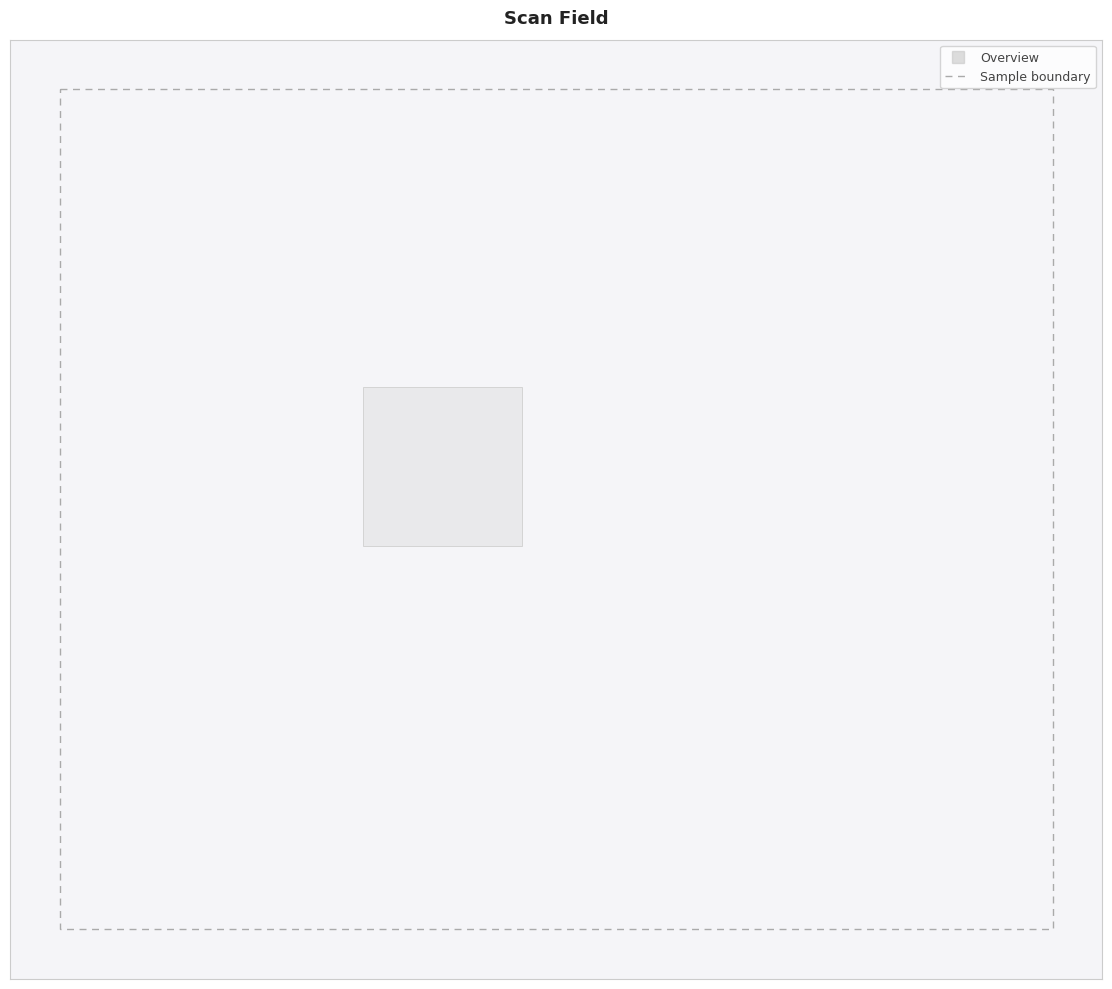

In [17]:
from workflow import read_scan_field, plot_scan_field

read_scan_field(ctx)
plot_scan_field(ctx)

## Step 3 - Focus map

Place **focus markers** on the scan field in **Navigator Expert**, then
run this cell. Runs the AF job at each marker, reads back z-wide, and
fits a surface model (constant, line, plane, or thin plate spline
depending on the number of markers).

[step 3] Focus positions (1):
  1. x=62487.8  y=40655.7 um
[job] 'AF Job' selected (slot 0)

[1/1] x=62488  y=40656  z-wide=1286.30 um

[step 3] Focus model: constant (1 points)
  Z mean:       1286.30 um
[step 3] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_06rn9e\focus_map.png


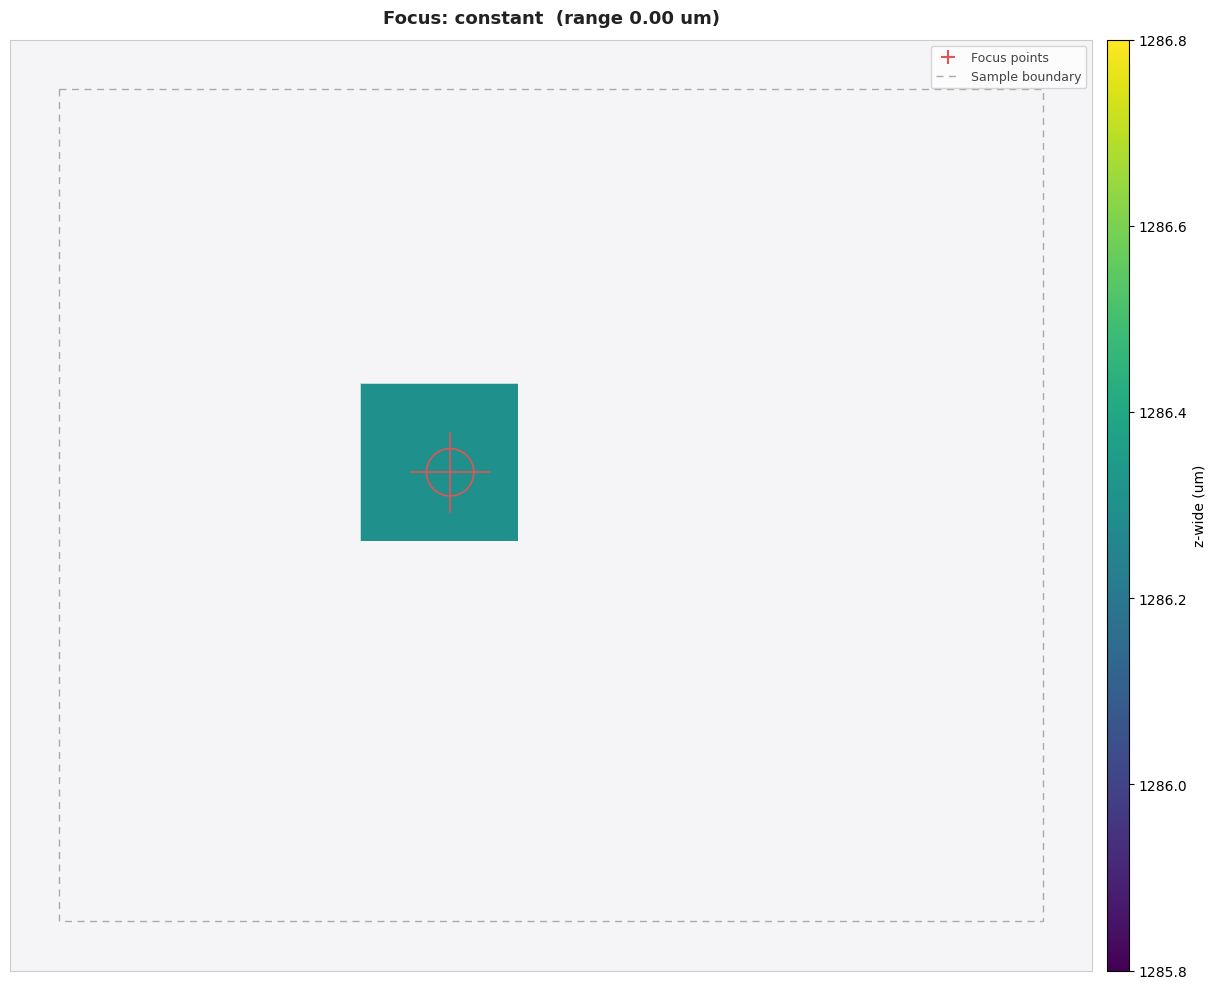

In [18]:
from workflow import build_focus_map

focus_map = build_focus_map(ctx)
focus_map.plot(ctx)

## Step 4 - Overview + live analysis

Acquires every tile in snake order, submits each to the analysis engine
for cellpose segmentation + pick selection. Drains results, deduplicates
picks, and filters out-of-limits targets.

In [ ]:
from workflow import run_overview_with_picks
from workflow.visualize import display_tile

picks = run_overview_with_picks(ctx, focus_map, on_tile=lambda e: display_tile(
    e, feedback_dir=ctx.run.layout.feedback_dir("overview-scan"),
))

### Step 4b - Overview visualization

Per-tile triptych: grayscale tile | segmentation overlay (all cells, random
colours) | picked cells (red mask). Reads analysis artifacts saved during
Step 4 — can be re-run without re-acquiring.

[visualize] Showing 1 tile(s).


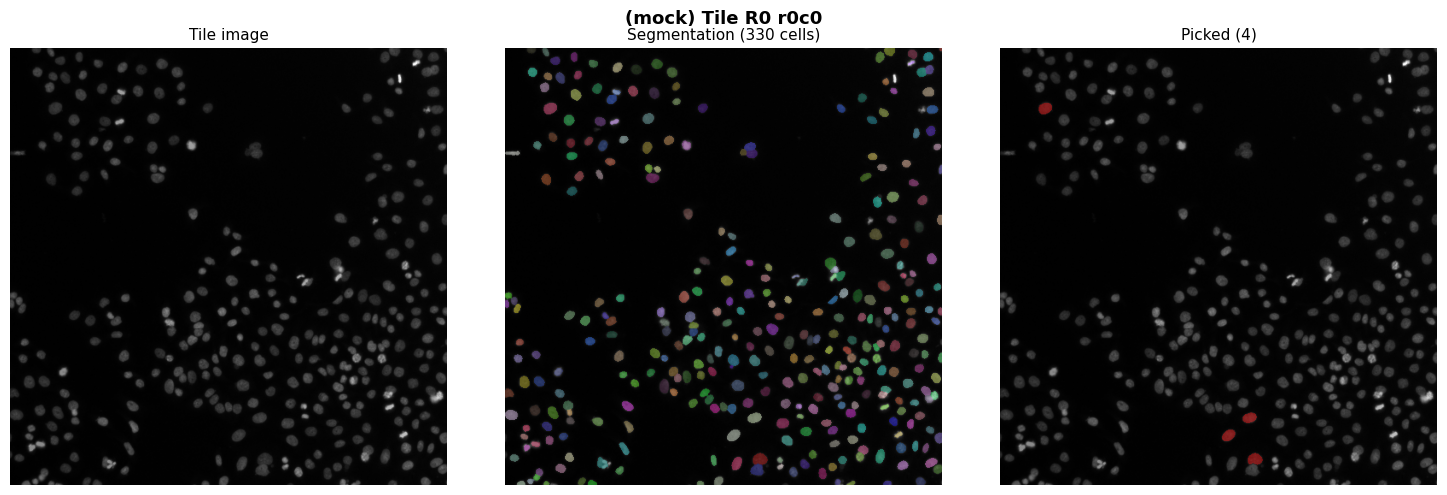

In [20]:
from workflow import plot_overview_tiles

plot_overview_tiles(
    ctx.run.layout.analysis_dir("overview-scan"),
    picks,
    feedback_dir=ctx.run.layout.feedback_dir("overview-scan"),
)

## Step 5 - Target acquisition

Switches to the target job and acquires each picked cell at high
magnification. Per-pick failure isolation: if one pick fails, the
rest still acquire.

In [ ]:
from workflow import acquire_targets
from workflow.visualize import display_target

records = acquire_targets(ctx, picks, on_target=lambda pick, rec: display_target(
    pick, rec,
    ctx.run.layout.analysis_dir("overview-scan"),
    feedback_dir=ctx.run.layout.feedback_dir("target-acquisition"),
))

### Step 5b - Target pair visualization

Side-by-side: cropped cell from overview tile (left) vs. newly acquired
high-res target image (right). Same display height; target shows higher
resolution.

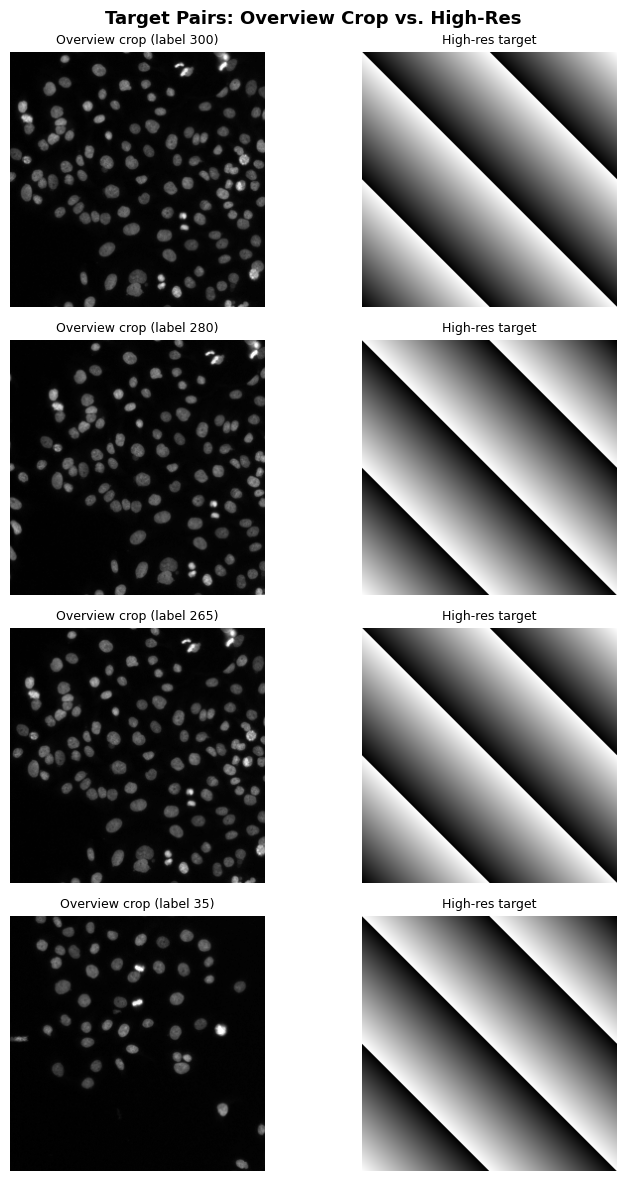

In [22]:
from workflow import plot_target_pairs

plot_target_pairs(
    ctx.run.layout.analysis_dir("overview-scan"),
    picks, records,
    feedback_dir=ctx.run.layout.feedback_dir("target-acquisition"),
)

## Step 6 - Results + cleanup

First write and inspect the summary and results plot. Then run the
**finish** cell to restore the source job and shut down the engine.

The **cleanup** cell at the bottom is a safety backstop for interrupted
runs - it is not part of the normal path (finish already shuts down).

[step 6] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_06rn9e\run_summary.json
[step 6] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_06rn9e\results.png


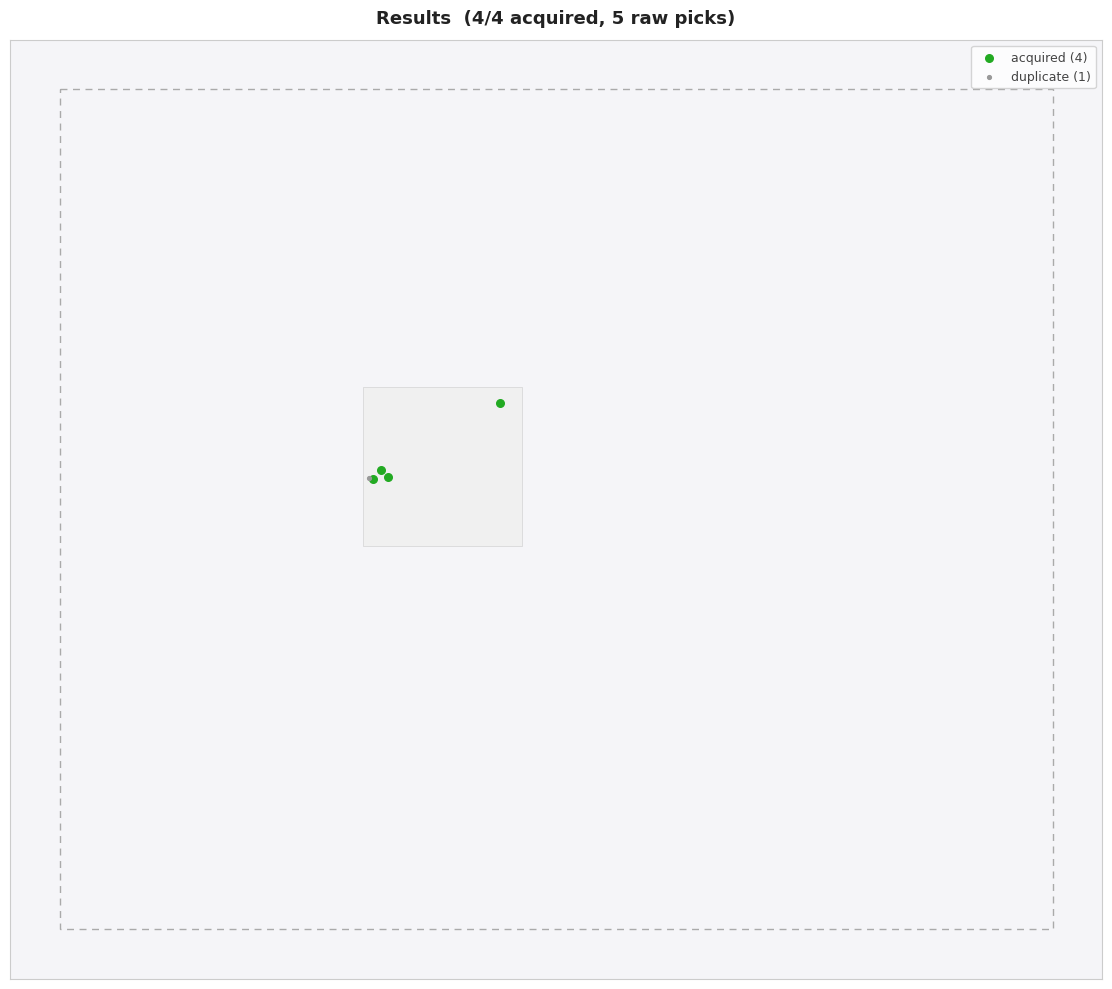

In [23]:
from workflow import write_summary, plot_results

write_summary(ctx, focus_map, picks, records)
plot_results(ctx, focus_map, picks, records)

In [24]:
from workflow import finish

finish(ctx)

[job] 'Overview' selected (slot 0)
[step 6] Restored source job (slot 0).
[step 6] Shutdown complete.


In [26]:
# Cleanup -- always safe to run (D20)
try:
    ctx.shutdown()
except NameError:
    pass